# Lab 5: Group Recommender Systems

## Section 1: Data Preparation and Exploration

### The MovieLens Dataset

[MovieLens](https://grouplens.org/datasets/movielens/) is one of the most popular (publicly) available datasets for benchmarking. In this notebook, we will work with the [1M](https://grouplens.org/datasets/movielens/1m/) version, which contains 1,000,209 anonymous ratings of approximately 3,900 movies made by 6,040 MovieLens users who joined MovieLens in 2000.

Let's load this data with pandas

In [5]:
from urllib.request import urlretrieve
import zipfile
import pandas as pd
import numpy as np
import random
import os

In [6]:
# If file exists, skip the download
data_file_path = "movielens/Movielens1M/"
data_file_name = data_file_path + "movielens_1m.zip"

# If directory does not exist, create
if not os.path.exists(data_file_path):
    os.makedirs(data_file_path)

if not os.path.exists(data_file_name):
    urlretrieve("https://files.grouplens.org/datasets/movielens/ml-1m.zip", data_file_name)

In [7]:
# unzip and read the *.dat files
dataFile = zipfile.ZipFile(data_file_path + "movielens_1m.zip")

ratings_path = dataFile.extract("ml-1m/ratings.dat", path= data_file_path)
users_path = dataFile.extract("ml-1m/users.dat",path= data_file_path)
movies_path = dataFile.extract("ml-1m/movies.dat",path= data_file_path)

### Let's take a look at the data

Let us focus on the ratings of users for items

In [8]:
import pandas as pd

In [9]:
ratings_df = pd.read_table(ratings_path, sep="::", names=["user", "item", "rating", "timestamp"])


display(ratings_df.head(10))

<ipython-input-9-4996280d8262>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ratings_df = pd.read_table(ratings_path, sep="::", names=["user", "item", "rating", "timestamp"])


,user,item,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368


In [10]:
# Check number of ratings per user
rating_per_user_df = ratings_df.groupby(['user']).count().sort_values(by="rating", ascending=False)
display(rating_per_user_df)

,item,rating,timestamp
user,,,
4169,2314,2314,2314
1680,1850,1850,1850
4277,1743,1743,1743
1941,1595,1595,1595
1181,1521,1521,1521
...,...,...,...
2530,20,20,20
3407,20,20,20
2884,20,20,20


In [11]:
# Check number of ratings per item
rating_per_item_df = ratings_df.groupby(['item']).count().sort_values(by="rating", ascending=False)
display(rating_per_item_df)

,user,rating,timestamp
item,,,
2858,3428,3428,3428
260,2991,2991,2991
1196,2990,2990,2990
1210,2883,2883,2883
480,2672,2672,2672
...,...,...,...
2213,1,1,1
2214,1,1,1
2217,1,1,1


(Optional) Homework: try to change min_ratings_per_item and observe the new results

In [12]:
# select items with the desidered number of ratings
min_ratings_per_item = 100

selected_items = list(rating_per_item_df.loc[rating_per_item_df['rating'] >= min_ratings_per_item].reset_index()['item'])

In [13]:
# select ratings for the selected items
display(ratings_df.shape)

selected_ratings_df = ratings_df.loc[ratings_df['item'].isin(selected_items)]
display(selected_ratings_df.shape)

(1000209, 4)

(942225, 4)

In [14]:
# Check again number of ratings per user
rating_per_user_df = selected_ratings_df.groupby(['user']).count().sort_values(by="rating", ascending=False)
display(rating_per_user_df)

,item,rating,timestamp
user,,,
4169,1568,1568,1568
1680,1422,1422,1422
4277,1366,1366,1366
1941,1339,1339,1339
1181,1318,1318,1318
...,...,...,...
1318,15,15,15
4365,15,15,15
4527,15,15,15


In [15]:
# Save dataset
selected_ratings_df[['user','item','rating']].to_csv("./ratings.csv", index=False)

In [16]:
import numpy as np

df = selected_ratings_df.groupby('item').agg({"rating": [np.sum, np.prod,np.min,np.max]})
display(df)
display(df['rating']['sum'].reset_index())

<ipython-input-16-a27bf35ac3f2>:3: FutureWarning: The provided callable <function sum at 0x7db007f59940> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = selected_ratings_df.groupby('item').agg({"rating": [np.sum, np.prod,np.min,np.max]})
<ipython-input-16-a27bf35ac3f2>:3: FutureWarning: The provided callable <function prod at 0x7db007f5a340> is currently using SeriesGroupBy.prod. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "prod" instead.
  df = selected_ratings_df.groupby('item').agg({"rating": [np.sum, np.prod,np.min,np.max]})
<ipython-input-16-a27bf35ac3f2>:3: FutureWarning: The provided callable <function min at 0x7db007f5a160> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mi

rating                             
        sum                 prod min max
item                                    
1      8613                    0   1   5
2      2244                    0   1   5
3      1442                    0   1   5
4       464                    0   1   5
5       890                    0   1   5
...     ...                  ...  ..  ..
3937    397                    0   1   5
3946    226  4731471213203816448   1   5
3948   3134                    0   1   5
3949   1251                    0   1   5
3952   1467                    0   1   5

[2019 rows x 4 columns]

,item,sum
0,1,8613
1,2,2244
2,3,1442
3,4,464
4,5,890
...,...,...
2014,3937,397
2015,3946,226
2016,3948,3134
2017,3949,1251


## Section 2: Synthetic Groups Generation

Question: Do you remember how many types of group that we have for group recommender systems?

In [17]:
import pandas as pd

ratings_df = pd.read_csv("./ratings.csv")
display(ratings_df.head(10))

,user,item,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5
5,1,1197,3
6,1,1287,5
7,1,2804,5
8,1,594,4
9,1,919,4


### Similarity evaluation

Evaluation of the similarity between all the pairs of users in the dataset.

In [18]:
# computing similarity between each pair of users

import numpy as np

user_matrix = ratings_df.pivot_table(columns='item', index='user', values='rating')

user_id_set = set(ratings_df['user'])
user_id_indexes = user_matrix.index.values
user_matrix = user_matrix.fillna(0)
numpy_array = user_matrix.to_numpy()
sim_matrix = np.corrcoef(numpy_array)

In [19]:
display(sim_matrix)

array([[ 1.        ,  0.06307674,  0.10011941, ..., -0.01543384,
         0.14675218,  0.08806549],
       [ 0.06307674,  1.        ,  0.12210112, ...,  0.04554203,
         0.01161514,  0.15544135],
       [ 0.10011941,  0.12210112,  1.        , ...,  0.10763032,
         0.06220201,  0.08878705],
       ...,
       [-0.01543384,  0.04554203,  0.10763032, ...,  1.        ,
         0.14596756,  0.07298994],
       [ 0.14675218,  0.01161514,  0.06220201, ...,  0.14596756,
         1.        ,  0.16791532],
       [ 0.08806549,  0.15544135,  0.08878705, ...,  0.07298994,
         0.16791532,  1.        ]])

### Visualization of the similarity distribution

Text(0.5, 0, "Pearson's Correlation Coeficient")

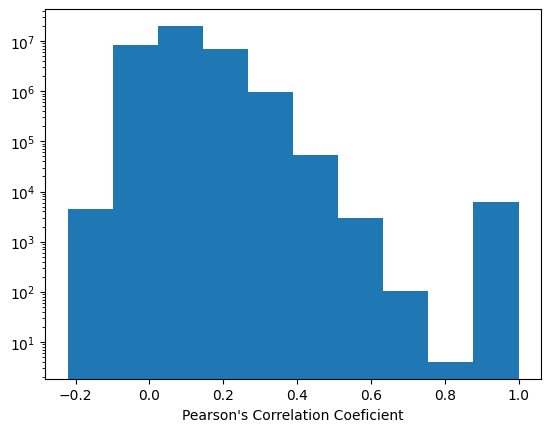

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(sim_matrix.flatten())
plt.yscale("log")
plt.xlabel("Pearson's Correlation Coeficient")

In [21]:
import numpy as np
import random

In [22]:
def compute_average_similarity(group, user_id_indexes, sim_matrix):
    similarities = list()

    for user_1 in group:
        user_1_index = user_id_indexes.tolist().index(user_1)
        for user_2 in group:
            user_2_index = user_id_indexes.tolist().index(user_2)
            if user_1 != user_2:
                similarities.append(sim_matrix[user_1_index][user_2_index])

    return np.mean(similarities)

In [23]:
def select_user_for_sim_group(group, sim_matrix, user_id_indexes, sim_threshold=0.4):
    ids_to_select_from = set()

    for member in group:
        member_index = user_id_indexes.tolist().index(member)
        indexes = np.where(sim_matrix[member_index] >= sim_threshold)[0].tolist()
        user_ids = [user_id_indexes[index] for index in indexes]
        ids_to_select_from = ids_to_select_from.union(set(user_ids))

    candidate_ids = ids_to_select_from.difference(set(group))

    if len(candidate_ids) == 0:
        return None
    else:
        selection = random.sample(list(candidate_ids), 1)
        return selection[0]

In [24]:
def generateSimilarGroups(user_id_indexes, user_id_set, similarity_matrix, group_sizes_to_create, group_number_to_create, sim_threshold):


    groups_list = list()

    for group_size in group_sizes_to_create:
        groups_size_list = list()
        while (len(groups_size_list) < group_number_to_create):

            group = random.sample(list(user_id_set), 1)
            while len(group) < group_size:
                new_member = select_user_for_sim_group(group,
                                                       similarity_matrix,
                                                       user_id_indexes,
                                                       sim_threshold=sim_threshold)
                if new_member is None:
                    break
                group.append(new_member)
            if len(group) == group_size:
                groups_size_list.append(
                    {
                        "group_size": group_size,
                        "group_similarity": 'similar',
                        "group_members": group,
                        "avg_similarity": compute_average_similarity(group, user_id_indexes, similarity_matrix)
                    }
                )
        groups_list.extend(groups_size_list)
        print(len(groups_list))
    return groups_list

In [25]:
def generateRandomGroups(user_id_indexes, user_id_set, similarity_matrix, group_sizes_to_create, group_number_to_create):

    groups_list = list()

    for group_size in group_sizes_to_create:
      for i in range(group_number_to_create):
        group = random.sample(list(user_id_set), group_size)
        groups_list.append(
            {
                "group_size": group_size,
                "group_similarity": 'random',
                "group_members": group,
                "avg_similarity": compute_average_similarity(group, user_id_indexes, similarity_matrix)
            }
        )
        print(len(groups_list))


    return groups_list

## Section 3: Now we will generate groups

In [26]:
group_number = 20
group_sizes_to_create = [2, 5]
similar_threshold = 0.5

similar_list = generateSimilarGroups(user_id_indexes, user_id_set, sim_matrix, group_sizes_to_create, group_number, similar_threshold)
random_list = generateRandomGroups(user_id_indexes, user_id_set, sim_matrix, group_sizes_to_create, group_number)

group_list = similar_list + random_list

20
40
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


In [27]:
group_dict = dict()
for group_id, group in zip(range(len(group_list)), group_list):
    group_dict[group_id] = group

display(group_dict)

{0: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [5338, 5997],
  'avg_similarity': 0.593030684179985},
 1: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [103, 4284],
  'avg_similarity': 0.534028036455979},
 2: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [949, 42],
  'avg_similarity': 0.5260386845171259},
 3: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [103, 4284],
  'avg_similarity': 0.534028036455979},
 4: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [876, 4417],
  'avg_similarity': 0.5018862656299343},
 5: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [4777, 3730],
  'avg_similarity': 0.5129430413653617},
 6: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [3108, 3823],
  'avg_similarity': 0.5123428592243444},
 7: {'group_size': 2,
  'group_similarity': 'similar',
  'group_members': [3671, 2575],
  'avg_similarity'

In [28]:
# simple similarity viewer per group
np.set_printoptions(precision=4, suppress=True)

idx = 75
member_index = [user_id_indexes.tolist().index(member) for member in group_dict[idx]["group_members"]]# Fill in
s = sim_matrix[member_index]
s[:,member_index]

array([[1.    , 0.0117, 0.1817, 0.0358, 0.0875],
       [0.0117, 1.    , 0.0051, 0.0309, 0.0359],
       [0.1817, 0.0051, 1.    , 0.0632, 0.0858],
       [0.0358, 0.0309, 0.0632, 1.    , 0.0066],
       [0.0875, 0.0359, 0.0858, 0.0066, 1.    ]])

In [29]:
import pickle
pickle.dump(group_dict, open("./group_composition.pkl", "wb"))

We explore group similarity for "similar" and "random"

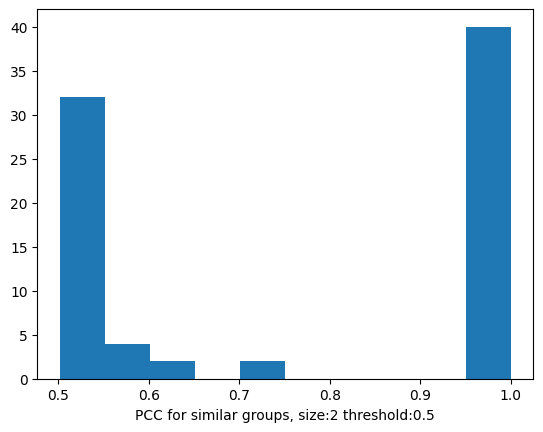

In [30]:
group_similarity = "similar"
group_size = 2

histogram_list = []
for gid in group_dict.keys():
    g = group_dict[gid]
    if g["group_similarity"] == group_similarity and g["group_size"] == group_size:
        member_index = [user_id_indexes.tolist().index(member) for member in g["group_members"]]
        s = sim_matrix[member_index]
        histogram_list.extend(s[:,member_index].flatten().tolist())


plt.hist(histogram_list)
#plt.yscale("log")
plt.xlabel("PCC for "+group_similarity+" groups, size:"+str(group_size)+" threshold:"+str(similar_threshold))
plt.savefig("pcc_"+group_similarity+"_"+str(group_size)+"_"+str(int(similar_threshold*10))+".png", dpi=300)

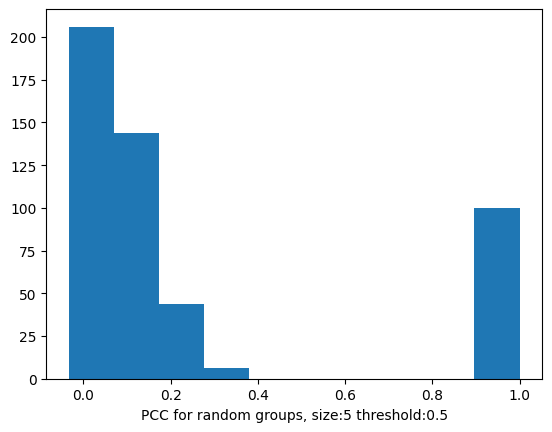

In [31]:
group_similarity = "random"
group_size = 5

histogram_list = []
for gid in group_dict.keys():
    g = group_dict[gid]
    if g["group_similarity"] == group_similarity and g["group_size"] == group_size:
      member_index = [user_id_indexes.tolist().index(member) for member in g["group_members"]]
      s = sim_matrix[member_index]
      histogram_list.extend(s[:, member_index].flatten().tolist())


plt.hist(histogram_list)
#plt.yscale("log")
plt.xlabel("PCC for "+group_similarity+" groups, size:"+str(group_size)+" threshold:"+str(similar_threshold))
plt.savefig("pcc_"+group_similarity+"_"+str(group_size)+"_"+str(int(similar_threshold*10))+".png", dpi=300)

In [32]:
groups_list = list()
for group in group_dict:
    groups_list.append(
        {
            'group_id': group,
            'group_size': group_dict[group]['group_size'],
            'group_similarity': group_dict[group]['group_similarity'],
            'group_members': group_dict[group]['group_members'],
            'avg_similarity': group_dict[group]['avg_similarity']
        }
    )

groups_df = pd.DataFrame.from_records(groups_list)
display(groups_df.head(10))

,group_id,group_size,group_similarity,group_members,avg_similarity
0,0,2,similar,"[5338, 5997]",0.593031
1,1,2,similar,"[103, 4284]",0.534028
2,2,2,similar,"[949, 42]",0.526039
3,3,2,similar,"[103, 4284]",0.534028
4,4,2,similar,"[876, 4417]",0.501886
5,5,2,similar,"[4777, 3730]",0.512943
6,6,2,similar,"[3108, 3823]",0.512343
7,7,2,similar,"[3671, 2575]",0.507330
8,8,2,similar,"[5558, 3715]",0.503908
9,9,2,similar,"[6008, 2539]",0.503323


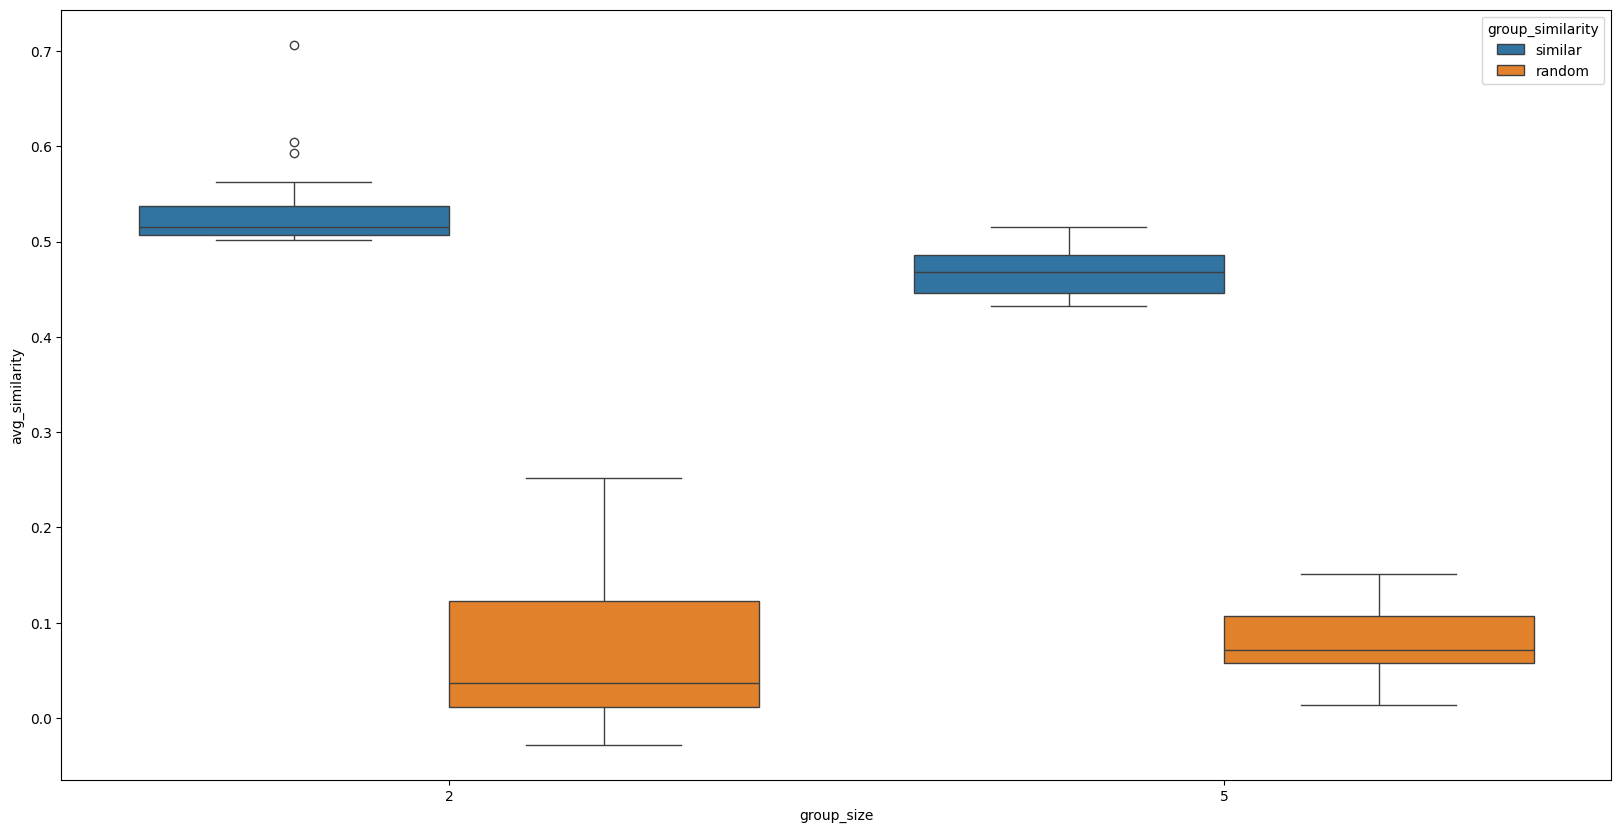

In [33]:
# Comparing groups internal average similarity between the different types and sizes

import seaborn as sns

plt.rcParams["figure.figsize"] = (20,10)
sns.boxplot(x = groups_df['group_size'],
            y = groups_df['avg_similarity'],
            hue = groups_df['group_similarity'])
import matplotlib.pyplot as plt

In [34]:
groups_df.to_csv("./group_composition.csv")

## Section 4: Train group recommendation model

In [33]:
!pip install lenskit
!pip install lenskit==0.14.4
!pip install numpy==1.25

  Using cached lenskit-2025.2.0-py3-none-any.whl.metadata (7.8 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached lenskit-2025.2.0-py3-none-any.whl (227 kB)
Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11

In [35]:
import pandas as pd
import pickle

from lenskit.algorithms import Recommender
from lenskit.algorithms.user_knn import UserUser
from lenskit.algorithms.item_knn import ItemItem
from sklearn.model_selection import train_test_split
from lenskit import batch, topn, util

In [36]:
ratings_df = pd.read_csv("./ratings.csv")
group_composition = pickle.load(open("./group_composition.pkl", "rb"))

len(group_composition)

80

In [37]:
import pickle
import os
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
import itertools

In [39]:
def create_per_user_group_choices(gr_composition, gr_choices):
    per_user_group_choices = pd.DataFrame(columns = ["user", "item", "rank"])
    for group_id in gr_composition:
        group = gr_composition[group_id]
        for member_id in group['group_members']:
            first_choice = gr_choices.loc[(gr_choices['group_id'] == group_id) &
                                          (gr_choices['rank'] == 1)]['item'].values[0]
            second_choice = gr_choices.loc[(gr_choices['group_id'] == group_id) &
                                           (gr_choices['rank'] == 2)]['item'].values[0]
            new_row1 = pd.DataFrame([[member_id, first_choice, 1]],
                                       columns = ["user", "item", "rank"])
            new_row2 = pd.DataFrame([[member_id, first_choice, 2]],
                                       columns = ["user", "item", "rank"])
            per_user_group_choices = pd.concat([per_user_group_choices, new_row1, new_row2],
                                               axis=0, ignore_index=True)

    return per_user_group_choices

In [42]:
def train_individual_rs_and_get_predictions(training_df, test_df):
    # Train lenskit CF user-user individual recommender system and predict ratings
    print("training")
    nNeighbors = 2
    print("nNeighbors hyperparameter:" + str(nNeighbors))

    user_user = UserUser(nNeighbors)
    recsys = Recommender.adapt(user_user)
    recsys.fit(training_df)

    print("evaluating predictions")
    # Evaluating predictions
    test_df['predicted_rating'] = recsys.predict(test_df)
    print("Done!")
    return test_df

In [ ]:
skf = StratifiedKFold(n_splits=2, random_state=42, shuffle=True)

print(datetime.now(), "Folds created!")
current_fold = 0
for train_index, test_index in skf.split(ratings_df, ratings_df['user']):
    print(">>> Start processing fold: Train", len(train_index), "Test:", len(test_index))

    # split train and test df
    train_df = ratings_df.iloc[train_index]
    test_df = ratings_df.iloc[test_index]

    # getting user-items pairs in the training set
    train_set_pairs = set(list(zip(train_df['user'].values,train_df['item'].values)))

    # create test_complete_df with all the possible user-items pairs in the test_df
    user_set = set(test_df['user'].values)
    item_set = set(test_df['item'].values)
    all_ui_values = list(itertools.product(user_set, item_set))
    test_pred_df = pd.DataFrame(all_ui_values, columns=['user', 'item'])

    print(datetime.now(), "Train individual RS and get predictions")
    # train individual rs and get predictions
    test_pred_df = train_individual_rs_and_get_predictions(train_df, test_pred_df)

    # correction for train set records (assuming repeated recommendations provide no value, therefore predicted_rating=0)
    train_set_pairs = train_set_pairs.intersection(set(all_ui_values))
    test_pred_df.set_index(["user","item"], inplace=True)
    # Convert train_set_pairs to a list before using it as an indexer
    test_pred_df.loc[list(train_set_pairs),"predicted_rating"] = 0.0
    test_pred_df.reset_index(inplace=True)

    path_to_fold = "./fold_"+str(current_fold)

    if not os.path.exists(path_to_fold):
        os.mkdir(path_to_fold)

    pickle.dump(train_df, open(path_to_fold+"/train_df.pkl", "wb"))
    pickle.dump(test_df, open(path_to_fold+"/test_df.pkl", "wb"))
    pickle.dump(test_pred_df, open(path_to_fold+"/test_pred_df.pkl", "wb"))

    current_fold = current_fold + 1

2025-03-23 17:09:56.276825 Folds created!
>>> Start processing fold: Train 471112 Test: 471113
2025-03-23 17:10:47.595779 Train individual RS and get predictions
training
nNeighbors hyperparameter:2
evaluating predictions
Done!
>>> Start processing fold: Train 471113 Test: 471112
2025-03-23 17:12:55.100958 Train individual RS and get predictions
training
nNeighbors hyperparameter:2
evaluating predictions
Done!


We now construct group recommendtions

In [44]:
# Additive aggregation

def generate_group_recommendations_for_group(group_ratings, recommendations_number):
    aggregated_df = group_ratings.groupby('item').sum()
    aggregated_df = aggregated_df.sort_values(by="predicted_rating", ascending=False).reset_index()[
        ['item', 'predicted_rating']]
    recommendation_list = list(aggregated_df.head(recommendations_number)['item'])
    return {"ADD": recommendation_list}

In [45]:
def generate_group_recommendations_forall_groups(test_df, group_composition, recommendations_number):
    group_recommendations = dict()
    for group_id in group_composition:

        # extract group info
        group = group_composition[group_id]
        group_size = group['group_size']
        group_similarity = group['group_similarity']
        group_members = group['group_members']

        group_ratings = test_df.loc[test_df['user'].isin(group_members)]

        group_rec = dict()

        group_rec = {**group_rec, **generate_group_recommendations_for_group(group_ratings, recommendations_number)}


        group_recommendations[group_id] = group_rec

    return group_recommendations

In [46]:
recommendations_number = 5

lst = os.listdir(".")
folds = [i for i in lst if (os.path.isdir("./"+i) and i.startswith("fold"))]

print(folds)

for f in folds:
    current_fold = int(f.replace("fold_",""))
    path_to_fold = "./"+f

    train_df = pickle.load(open(path_to_fold+"/train_df.pkl", "rb"))
    test_df = pickle.load(open(path_to_fold+"/test_df.pkl", "rb"))
    test_pred_df = pickle.load(open(path_to_fold+"/test_pred_df.pkl", "rb"))

    print(datetime.now(), f+": Generate GRS for all the aggregation strategies and all the groups")
    # - generate the recommendations for all the aggregation strategies and all the groups
    group_recommendations = generate_group_recommendations_forall_groups(test_pred_df, group_composition, 5)
    print(datetime.now(), f+": Done")

    pickle.dump(group_recommendations, open(path_to_fold+"/group_recommendations.pkl", "wb"))

['fold_1', 'fold_0']
2025-03-23 17:14:09.203016 fold_1: Generate GRS for all the aggregation strategies and all the groups
2025-03-23 17:14:16.526003 fold_1: Done
2025-03-23 17:14:16.715442 fold_0: Generate GRS for all the aggregation strategies and all the groups
2025-03-23 17:14:24.600641 fold_0: Done


# End of Lab!

References:

[1] Offline evaluation of group recommender systems. RecSys 2020